# 📊 Matplotlib Basics and Chart Interpretation

**Project:** Retail Sales Analysis (Continued)  
---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. Understand **why** data visualization is important in EDA
2. Know **which chart to use** for which type of question
3. Create **Line charts, Bar charts, Scatter plots, Histograms, and Boxplots** using Matplotlib
4. Add **labels, titles, legends, and gridlines** to make charts readable
5. Write **simple business insights** from every chart you create

---

## 📌 Prerequisites

You should already be comfortable with:
- Loading data with Pandas
- Data cleaning (handling missing values, duplicates, type conversion)
- Feature engineering (creating new columns, `pd.cut()`, `np.where()`)
- Basic data exploration (`head()`, `describe()`, `value_counts()`, etc.)

---

## 1. What is Data Visualization?

Data visualization means **representing data using charts and graphs** instead of just tables and numbers.

**Think of it this way:**
- A table with 100 rows of revenue data is hard to read.
- A single line chart can instantly show you whether revenue is going **up or down**.

> "A picture is worth a thousand rows of data."

### Why are charts important in EDA?

| Purpose | What you want to know | Best chart |
|---|---|---|
| **Trend** | How does revenue change over time? | Line chart |
| **Comparison** | Which category sells the most? | Bar chart |
| **Relationship** | Does higher price mean higher revenue? | Scatter plot |
| **Distribution** | How is revenue spread across transactions? | Histogram |
| **Outliers** | Are there unusually high or low values? | Boxplot |

**Keep this table handy!** Before creating any chart, always ask yourself:  
*"What question am I trying to answer?"*

---

## 2. What is Matplotlib?

**Matplotlib** is the most popular Python library for creating charts and graphs.

- It was created in 2003 and is still the foundation for most Python plotting.
- We use the `pyplot` module from Matplotlib — commonly imported as `plt`.
- Almost every data science project uses Matplotlib at some stage.

We will use the **simple, beginner-friendly style** of Matplotlib (called the "pyplot" interface).  
This means we call functions like `plt.plot()`, `plt.bar()`, etc. directly.

---

## 3. Import Libraries

In [5]:
# ============================================
# Import the libraries we need
# ============================================
# !pip install matplotlib
# !pip install  openpyxl
import pandas as pd                        # For data handling
import numpy as np                         # For numerical operations
import matplotlib.pyplot as plt            # For creating charts


print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---

## 4. Load the Dataset

In [6]:
# ============================================
# Load the Retail Sales dataset
# ============================================

df = pd.read_excel("DataSet_used\\sales_data.xlsx")
# df = pd.read_excel("DataSet_used\\sales_data_cleaned.xlsx")

# Quick look at the data
print("Shape of data:", df.shape)
df.head()

Shape of data: (85, 13)


,Transaction_ID,Date,Product,Category,Price,Quantity,Revenue,Day,DayOfWeek,WeekNumber,Revenue_Per_Unit,Revenue_Tier,Is_High_Value
0,TXN-1001,2026-01-07,Headphones,Accessories,150,2,300,7,Wednesday,2,150,Low,No
1,TXN-1002,2026-01-20,Smartphone,Electronics,600,4,2400,20,Tuesday,4,600,High,Yes
2,TXN-1003,2026-01-29,Smartphone,Electronics,600,3,1800,29,Thursday,5,600,Medium,Yes
3,TXN-1004,2026-01-15,Headphones,Accessories,150,1,150,15,Thursday,3,150,Low,No
4,TXN-1005,2026-01-11,Headphones,Accessories,150,4,600,11,Sunday,2,150,Medium,No


---

## 5. Quick Data Cleaning (Recap)

Since this is a messy dataset, let's quickly clean it before we start making charts.  
You have already learned all of these steps in earlier notebooks!

In [7]:
# ============================================
# Quick cleaning — we've learned this before!
# ============================================

# Step 1: Drop rows where critical columns are missing
df = df.dropna(subset=['Transaction_ID', 'Date', 'Product', 'Category', 'Price'])

# Step 2: Remove duplicates
df = df.drop_duplicates()

# Step 3: Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Step 4: Clean text columns — strip whitespace and standardize case
df['Product'] = df['Product'].str.strip().str.title()
df['Category'] = df['Category'].str.strip().str.title()

# Step 5: Recalculate Revenue to be safe
df['Revenue'] = df['Price'] * df['Quantity']

# Step 6: Feature Engineering — extract Day from date
df['Day'] = df['Date'].dt.day

print("✅ Data cleaned!")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head()

✅ Data cleaned!
Rows: 85 | Columns: 13


,Transaction_ID,Date,Product,Category,Price,Quantity,Revenue,Day,DayOfWeek,WeekNumber,Revenue_Per_Unit,Revenue_Tier,Is_High_Value
0,TXN-1001,2026-01-07,Headphones,Accessories,150,2,300,7,Wednesday,2,150,Low,No
1,TXN-1002,2026-01-20,Smartphone,Electronics,600,4,2400,20,Tuesday,4,600,High,Yes
2,TXN-1003,2026-01-29,Smartphone,Electronics,600,3,1800,29,Thursday,5,600,Medium,Yes
3,TXN-1004,2026-01-15,Headphones,Accessories,150,1,150,15,Thursday,3,150,Low,No
4,TXN-1005,2026-01-11,Headphones,Accessories,150,4,600,11,Sunday,2,150,Medium,No


In [8]:
# ============================================
# Quick sanity check on cleaned data
# ============================================

print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nUnique Products:", df['Product'].unique())
print("Unique Categories:", df['Category'].unique())

Data types:
Transaction_ID                 str
Date                datetime64[us]
Product                        str
Category                       str
Price                        int64
Quantity                     int64
Revenue                      int64
Day                          int32
DayOfWeek                      str
WeekNumber                   int64
Revenue_Per_Unit             int64
Revenue_Tier                   str
Is_High_Value                  str
dtype: object

Missing values:
Transaction_ID      0
Date                0
Product             0
Category            0
Price               0
Quantity            0
Revenue             0
Day                 0
DayOfWeek           0
WeekNumber          0
Revenue_Per_Unit    0
Revenue_Tier        0
Is_High_Value       0
dtype: int64

Unique Products: <ArrowStringArray>
['Headphones', 'Smartphone', 'Laptop', 'Smartwatch', 'Tablet']
Length: 5, dtype: str
Unique Categories: <ArrowStringArray>
['Accessories', 'Electronics']
Length: 2, d

---

## 6. Understanding the Basic Chart Structure

Every Matplotlib chart follows these steps:

```python
# Step 1: Set the figure size (optional but recommended)
plt.figure(figsize=(10, 5))

# Step 2: Create the chart
plt.plot(x_data, y_data)

# Step 3: Add labels and title
plt.xlabel('X-axis label')
plt.ylabel('Y-axis label')
plt.title('Chart Title')

# Step 4: Show the chart
plt.show()
```

**Key points:**
- `plt.figure(figsize=(width, height))` — controls chart size in inches
- `plt.xlabel()`, `plt.ylabel()` — label the axes so people know what they're looking at
- `plt.title()` — give every chart a clear title
- `plt.show()` — displays the chart

Let's now create each chart type one by one!

---

## 7. Line Chart — For Trends Over Time 📈

**When to use:** When you want to see how something **changes over time**.  
**Business question:** *"How does daily revenue change throughout the month?"*

In [9]:
# ============================================
# Prepare data: Total revenue per day
# ============================================

# Group by Date, sum up revenue for each day
daily_revenue = df.groupby('Date')['Revenue'].sum()

# Let's look at this data before plotting
print("Daily Revenue (first 5 days):")
print(daily_revenue)
print("\nTotal days:", len(daily_revenue))

Daily Revenue (first 5 days):
Date
2026-01-01     1200
2026-01-02     5400
2026-01-03     3600
2026-01-04     5400
2026-01-05      150
2026-01-06     5150
2026-01-07     4850
2026-01-08     5650
2026-01-09      550
2026-01-10     2000
2026-01-11      750
2026-01-12     4500
2026-01-14     2400
2026-01-15     7550
2026-01-16     1600
2026-01-17      600
2026-01-18     4600
2026-01-19     2400
2026-01-20     6400
2026-01-21    10750
2026-01-22     8800
2026-01-23     4600
2026-01-24      700
2026-01-25     1400
2026-01-26     3200
2026-01-28     2850
2026-01-29     9450
2026-01-30     9000
2026-01-31     1600
Name: Revenue, dtype: int64

Total days: 29


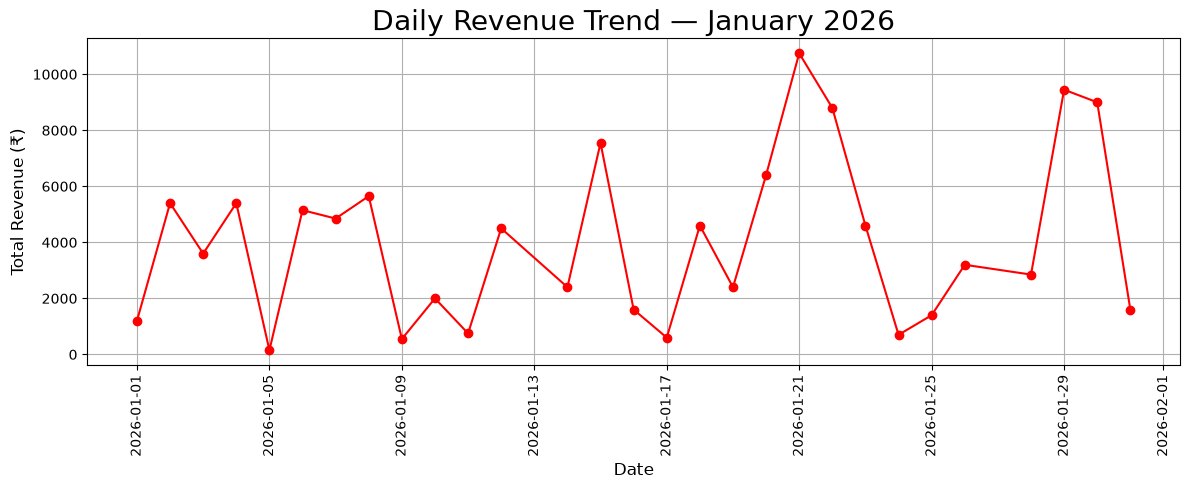

In [ ]:
# ============================================
# LINE CHART: Revenue trend by date
# ============================================

# Step 1: Set figure size
plt.figure(figsize=(12, 5))

# Step 2: Create line chart
plt.plot(daily_revenue.index, daily_revenue.values,color='red', marker='o')

# Step 3: Add labels and title
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.title('Daily Revenue Trend — January 2026', fontsize=20)

# Step 4: Add grid for easier reading
plt.grid(True)

# Step 5: Rotate x-axis date labels so they don't overlap
plt.xticks(daily_revenue.index,rotation=90)

# Step 6: Adjust layout so nothing gets cut off
plt.tight_layout()

# Step 7: Show the chart
plt.show()

### 📝 How to Read This Chart

- The **x-axis** shows dates and the **y-axis** shows total revenue.
- Each **dot** represents one day's total revenue.
- **Upward slopes** mean revenue is increasing; **downward slopes** mean it's decreasing.
- Look for **peaks** (best days) and **dips** (slowest days).

### 💡 Sample Business Insight

> *"Revenue fluctuates throughout January. We can see some peak days where revenue was significantly higher — these could correspond to weekends or promotional events. The business could investigate what drove those spikes."*

---

**Tip for writing insights:**
1. What does the chart show? (Describe the trend)
2. What stands out? (Any peaks, dips, or patterns?)
3. Why might this matter for the business?

---

## 8. Bar Chart — For Comparison 📊

**When to use:** When you want to **compare values across categories**.  
**Business question:** *"Which product generates the most revenue?"*

In [28]:
# ============================================
# Prepare data: Revenue by Product
# ============================================

# Group by Product, sum up revenue
product_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

print("Revenue by Product:")
print(product_revenue)

Revenue by Product:
Product
Laptop        60000
Smartphone    22800
Tablet        19600
Smartwatch     9000
Headphones     5700
Name: Revenue, dtype: int64


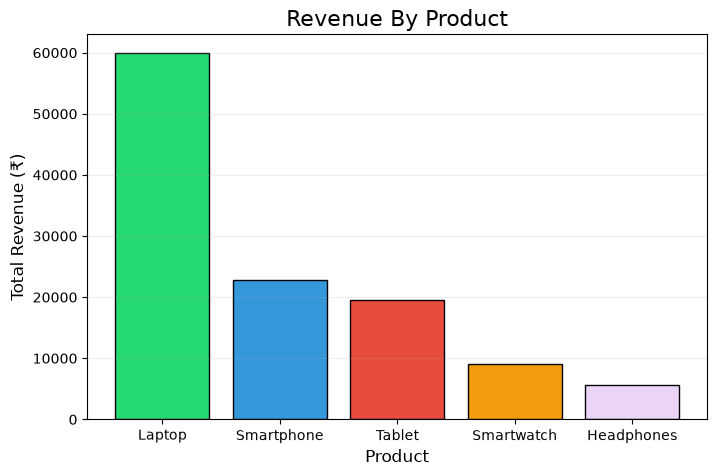

In [ ]:
# ============================================
# BAR CHART: Revenue by Product
# ============================================

# Set figure size
plt.figure(figsize=(8, 5))

# Create bar chart with custom colors
colors = ["#25db71", '#3498db', '#e74c3c', '#f39c12', "#ecd4f6"]
plt.bar(product_revenue.index, product_revenue.values, color=colors, edgecolor='black')

# Add labels and title
plt.xlabel('Product', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.title('Revenue By Product', fontsize = 16)
# Add grid on y-axis for easier comparison
plt.grid(axis='y', alpha=0.2) # aplha marks opacity

# plt.tight_layout()
plt.show()

### 📝 How to Read This Chart

- Each **bar** represents one product.
- The **height** of the bar shows total revenue for that product.
- Bars are sorted from highest to lowest revenue (we did `sort_values(ascending=False)`).

### 💡 Sample Business Insight

> *"Laptop generates the highest revenue, which makes sense given its higher price point. The business should ensure sufficient Laptop stock to maintain this revenue stream."*

Category
Accessories     14700
Electronics    102400
Name: Revenue, dtype: int64


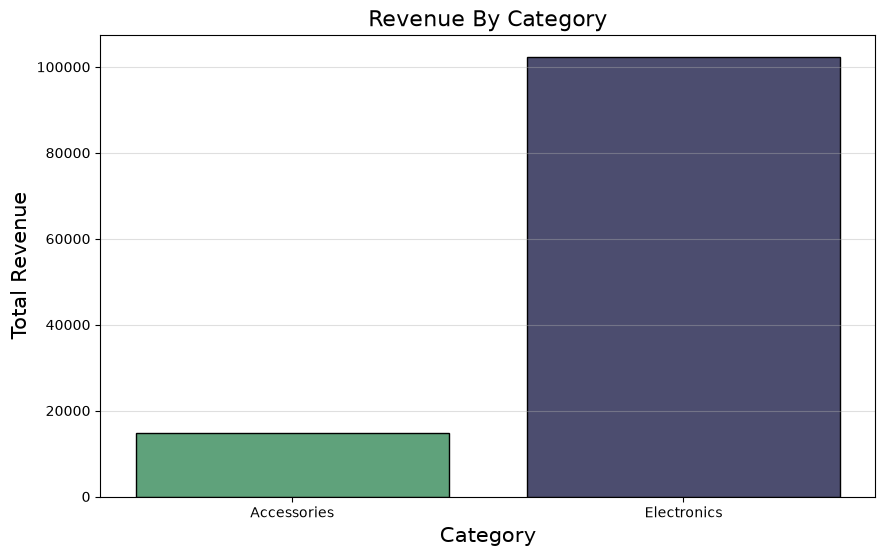

In [35]:
categor_rev = df.groupby('Category')['Revenue'].sum().sort_values(ascending=True)

print(categor_rev)

plt.figure(figsize=(10,6))

colors = ["#5fa27b", "#4c4d6f"]
plt.bar(categor_rev.index, categor_rev.values, color = colors, edgecolor = 'black')

plt.xlabel('Category',fontsize= 15)
plt.ylabel('Total Revenue',fontsize= 15)
plt.title('Revenue By Category',fontsize= 16)

plt.grid(axis= 'y', alpha = 0.4)

plt.show()


Category
Accessories     14700
Electronics    102400
Name: Revenue, dtype: int64


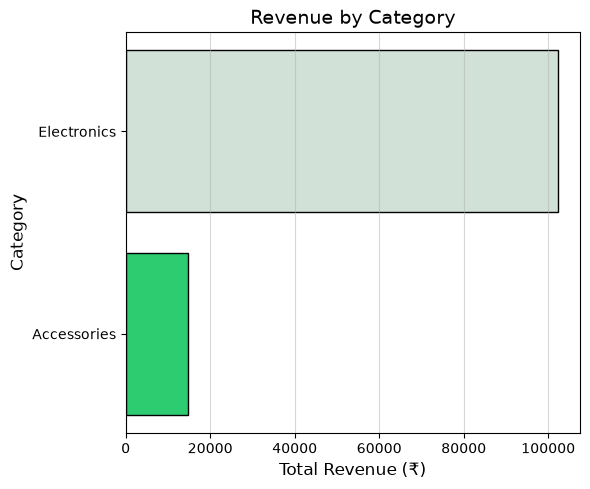

In [13]:
# ============================================
# BAR CHART #2: Revenue by Category
# ============================================

# Group by Category
category_revenue = df.groupby('Category')['Revenue'].sum()
print(category_revenue)
plt.figure(figsize=(6, 5))

# Horizontal bar chart using barh() — useful when labels are long
plt.barh(category_revenue.index, category_revenue.values, color=['#2ecc71',"#d1e1d8"], edgecolor='black')

plt.xlabel('Total Revenue (₹)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.title('Revenue by Category', fontsize=14)
plt.grid(axis='x',alpha=0.5)

plt.tight_layout()
plt.show()

### 💡 Sample Business Insight

> *"Electronics category dominates revenue compared to Accessories. This is expected since Electronics includes higher-priced items like Laptops and Smartphones."*

---

## 9. Scatter Plot — For Relationships 🔵

**When to use:** When you want to check if there is a **relationship between two numeric columns**.  
**Business question:** *"Is there a relationship between Price and Revenue?"*

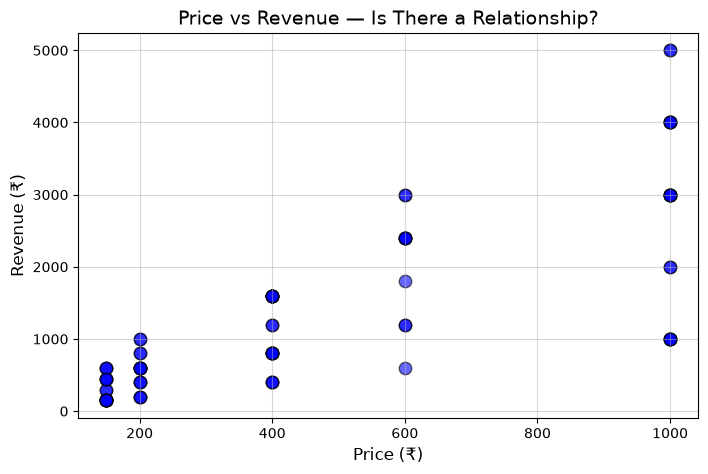

In [48]:
# ============================================
# SCATTER PLOT: Price vs Revenue
# ============================================

plt.figure(figsize=(8, 5))
# x=[1,2,3,4,5,6,7,8,9,10]
# y=[10,9,8,7,6,5,4,3,2,1]
# Each dot = one transaction
plt.scatter(df['Price'], df['Revenue'], color='blue', alpha=0.6, edgecolors='black', s=80)

# alpha=0.6 makes dots slightly transparent so overlapping dots are visible
# s=60 controls dot size

plt.xlabel('Price (₹)', fontsize=12)
plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Price vs Revenue — Is There a Relationship?', fontsize=14)
plt.grid(True, alpha=0.5)

plt.show()

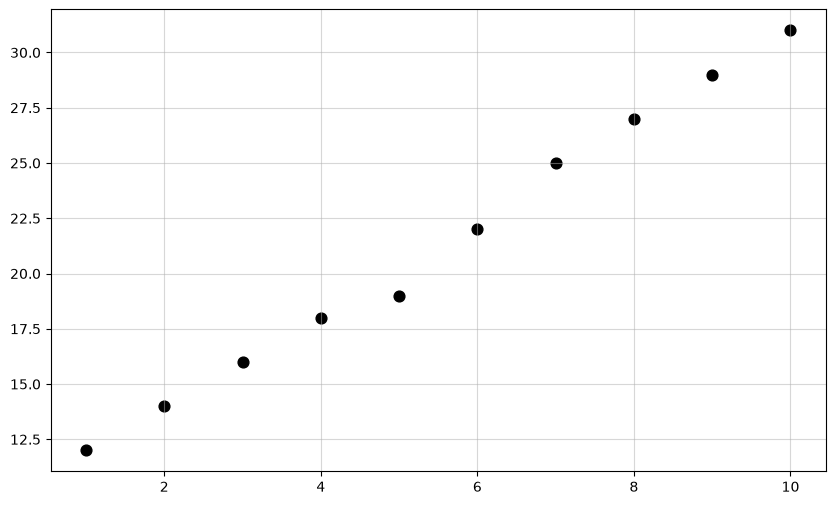

In [46]:
plt.figure(figsize = (10,6))
x = [1,2,3,4,5,6,7,8,9,10]
y = [12,14,16,18,19,22,25,27,29,31]
plt.scatter(x, y, color = 'black', s = 60)

plt.grid(True, alpha =0.5)
plt.show()


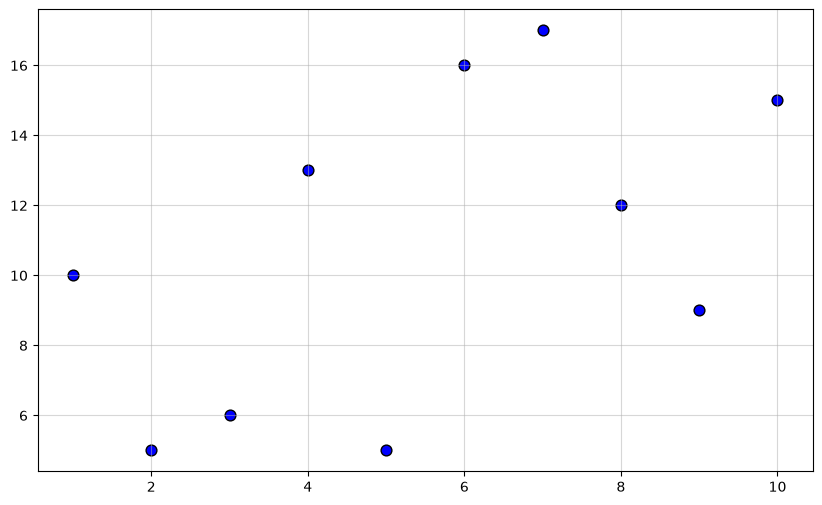

In [47]:
plt.figure(figsize = (10,6))
x = [1,2,3,4,5,6,7,8,9,10]
y = [10,5,6,13,5,16,17,12,9,15]
plt.scatter(x, y, color = 'blue', s = 60, edgecolors="black")

plt.grid(True, alpha =0.5)
plt.show()

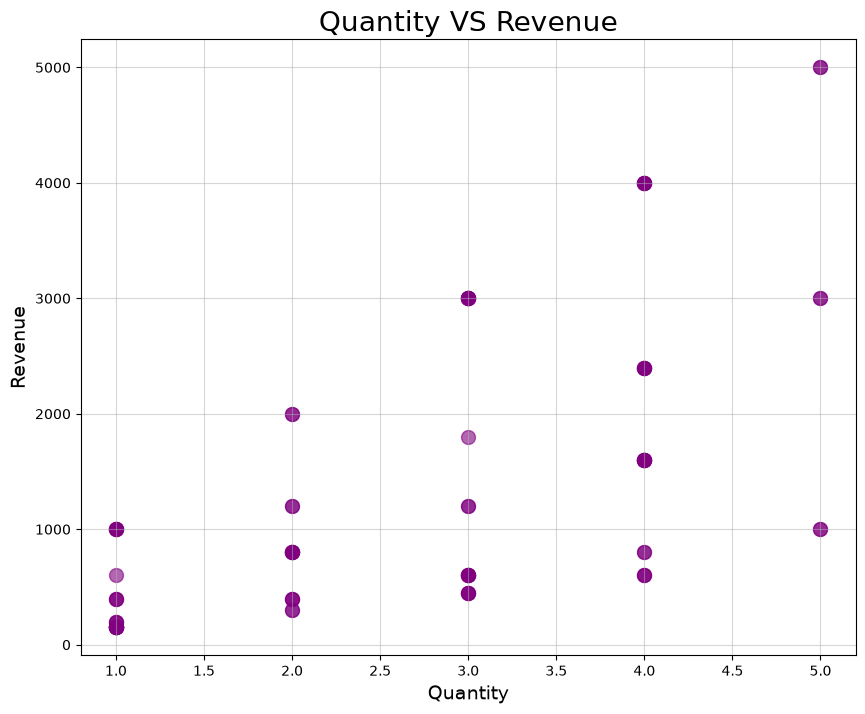

In [50]:
plt.figure(figsize = (10,8))
plt.scatter(df['Quantity'], df['Revenue'], color = 'purple', alpha = 0.6, s = 100)

plt.xlabel("Quantity", fontsize = 14)
plt.ylabel("Revenue", fontsize = 14)
plt.title("Quantity VS Revenue", fontsize = 20)

plt.grid(True, alpha = 0.5)

plt.show()



### 📝 How to Read This Chart

- Each **dot** represents one transaction.
- **x-axis** = Price of the product, **y-axis** = Revenue from that transaction.
- If dots go **upward from left to right**, it means higher price tends to mean higher revenue (**positive relationship**).
- If dots are **scattered randomly**, there is **no clear relationship**.

### 💡 Sample Business Insight

> *"There is a general positive trend — higher-priced products tend to generate higher revenue. However, revenue also depends on quantity sold, so some lower-priced items with high quantity can also generate good revenue."*

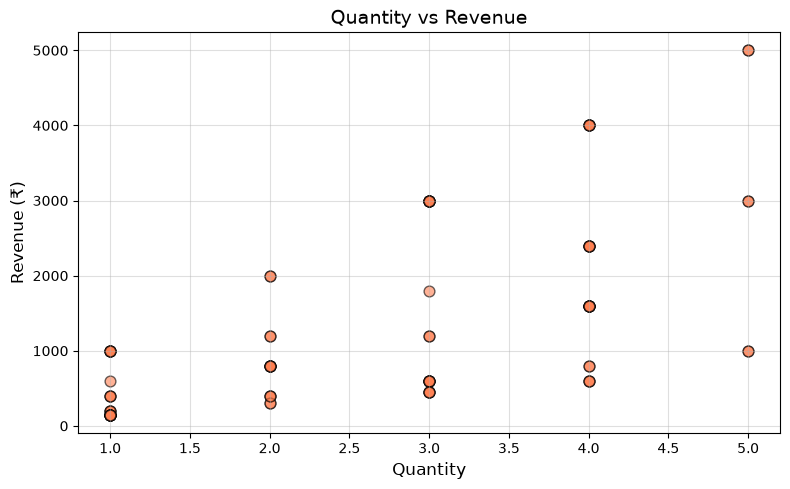

In [ ]:
# ============================================
# SCATTER PLOT #2: Quantity vs Revenue
# ============================================

plt.figure(figsize=(8, 5))

plt.scatter(df['Quantity'], df['Revenue'], color='coral', alpha=0.6, edgecolors='black', s=60)

plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Revenue (₹)', fontsize=12)
plt.title('Quantity vs Revenue', fontsize=14)
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()